# Exploring Oil Prices (Moving Average model) 🛢
------------------------
**Dr. Dave Wanik - University of Connecticut**

In [535]:
# https://drive.google.com/file/d/141-Id1X1cfUBV4NsWtFP8aG1YekJ25zc/view?usp=sharing
!gdown 141-Id1X1cfUBV4NsWtFP8aG1YekJ25zc

Downloading...
From: https://drive.google.com/uc?id=141-Id1X1cfUBV4NsWtFP8aG1YekJ25zc
To: /content/ctheatingoilregionalretailpricespdf.csv
100% 6.17k/6.17k [00:00<00:00, 15.2MB/s]


In [536]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 🔴 Read the data

In [537]:
df = pd.read_csv('/content/ctheatingoilregionalretailpricespdf.csv',
                 skiprows=1)

In [538]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATE             205 non-null    object 
 1   CT AVERAGE ($)   205 non-null    float64
 2   CT HIGH ($)      205 non-null    float64
 3   CT LOW ($)       205 non-null    float64
dtypes: float64(3), object(1)
memory usage: 6.5+ KB


In [539]:
df.head()

,DATE,CT AVERAGE ($),CT HIGH ($),CT LOW ($)
0,10/7/2019,2.743,3.849,2.329
1,10/14/2019,2.788,3.849,2.340
2,10/21/2019,2.770,3.849,2.299
3,10/28/2019,2.790,3.739,2.379
4,11/4/2019,2.803,3.999,2.340


# 🔴 Clean the data

## Rename columns

In [540]:
# old column names - see the spaces?
df.columns

Index(['DATE ', 'CT AVERAGE ($) ', 'CT HIGH ($) ', 'CT LOW ($) '], dtype='object')

In [541]:
# prompt: rename a column from 'CT AVERAGE ($)' to 'AVG'

df.rename(columns={'CT AVERAGE ($) ':'AVG'}, inplace=True)
df.rename(columns={'CT HIGH ($) ':'HIGH'}, inplace=True)
df.rename(columns={'CT LOW ($) ':'LOW'}, inplace=True)
df.rename(columns={'DATE ':'DATE'}, inplace=True)
df.head()


,DATE,AVG,HIGH,LOW
0,10/7/2019,2.743,3.849,2.329
1,10/14/2019,2.788,3.849,2.340
2,10/21/2019,2.770,3.849,2.299
3,10/28/2019,2.790,3.739,2.379
4,11/4/2019,2.803,3.999,2.340


In [542]:
df.columns # simplified!

Index(['DATE', 'AVG', 'HIGH', 'LOW'], dtype='object')

<Axes: >

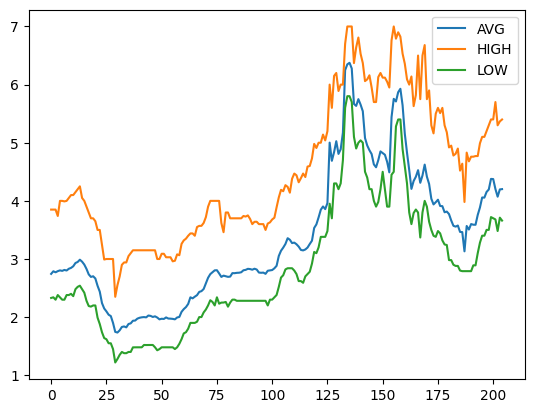

In [543]:
df.plot()

## Make use of datetime for `DATE`

In [544]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.head()

,DATE,AVG,HIGH,LOW
0,2019-10-07,2.743,3.849,2.329
1,2019-10-14,2.788,3.849,2.340
2,2019-10-21,2.770,3.849,2.299
3,2019-10-28,2.790,3.739,2.379
4,2019-11-04,2.803,3.999,2.340


## Set date as index

In [545]:
df.index = df['DATE']

In [546]:
del df['DATE']

In [547]:
df.head()

,AVG,HIGH,LOW
DATE,,,
2019-10-07,2.743,3.849,2.329
2019-10-14,2.788,3.849,2.340
2019-10-21,2.770,3.849,2.299
2019-10-28,2.790,3.739,2.379
2019-11-04,2.803,3.999,2.340


# 🔴 Explore the data

## Basic plot

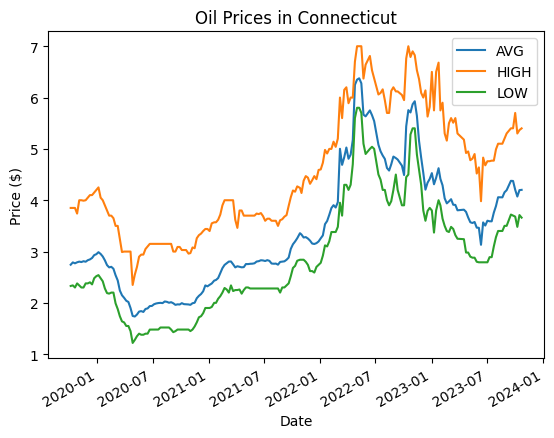

In [548]:
df.plot()
plt.title('Oil Prices in Connecticut')
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.show() # gets rid of annoying text

## Summary stats

In [549]:
df.describe()

,AVG,HIGH,LOW
count,205.000000,205.000000,205.000000
mean,3.365898,4.490590,2.821420
std,1.145472,1.195111,1.085171
min,1.734000,2.349000,1.219000
25%,2.676000,3.599000,2.180000
50%,2.987000,4.140000,2.520000
75%,4.195000,5.400000,3.500000
max,6.374000,6.999000,5.800000


## Boxplot

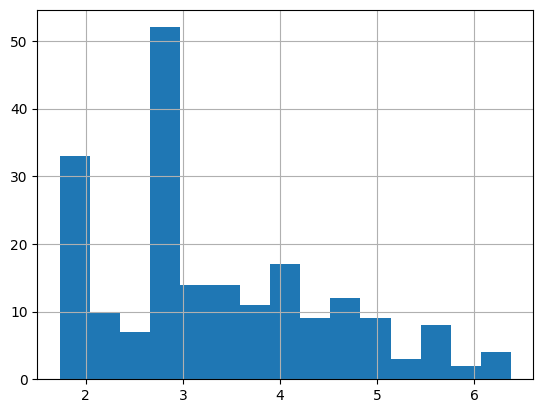

In [550]:
df['AVG'].hist(bins=15)
plt.show()

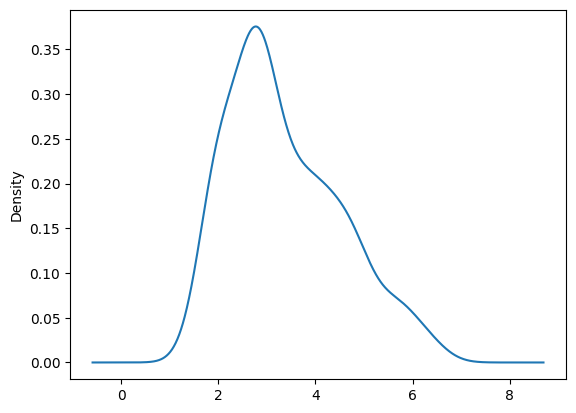

In [551]:
## KDE (like a PDF)
df['AVG'].plot.kde()
plt.show()

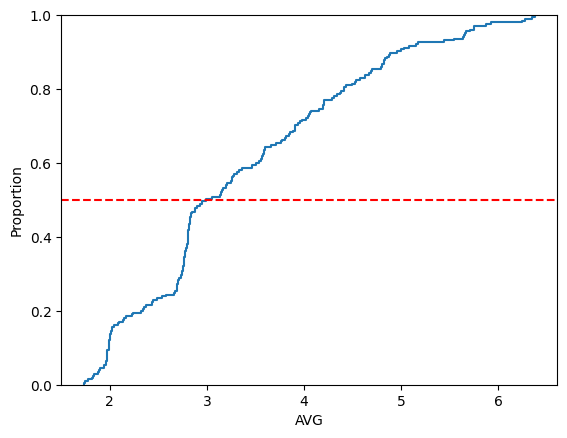

In [552]:
# prompt: make a cdf plot of the df['AVG'] column and add a horizontal line at proportion = 0.5

import seaborn as sns

# Create the CDF plot
sns.ecdfplot(df['AVG'])

# Add a horizontal line at proportion = 0.5
plt.axhline(y=0.5, color='red', linestyle='dashed')

# Show the plot
plt.show()


# 🔴 Make a moving average model

In [553]:
tmp = df['AVG']
tmp = pd.DataFrame(tmp)
tmp

,AVG
DATE,
2019-10-07,2.743
2019-10-14,2.788
2019-10-21,2.770
2019-10-28,2.790
2019-11-04,2.803
...,...
2023-09-25,4.374
2023-10-02,4.203
2023-10-09,4.071


Check out the documentation:

*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html



In [554]:
tmp['rolling3_cheating'] = tmp['AVG'].rolling(window=3).mean()
tmp.head()

,AVG,rolling3_cheating
DATE,,
2019-10-07,2.743,NaN
2019-10-14,2.788,NaN
2019-10-21,2.770,2.767000
2019-10-28,2.790,2.782667
2019-11-04,2.803,2.787667


In [555]:
(2.743 + 2.788 + 2.770)/3

2.767

## Data Leakage?!

In [556]:
tmp['rolling3_correct'] = tmp['rolling3_cheating'].shift(1)
tmp.head()

,AVG,rolling3_cheating,rolling3_correct
DATE,,,
2019-10-07,2.743,NaN,NaN
2019-10-14,2.788,NaN,NaN
2019-10-21,2.770,2.767000,NaN
2019-10-28,2.790,2.782667,2.767000
2019-11-04,2.803,2.787667,2.782667


### Drop NA values

In [557]:
tmp.dropna(inplace=True)

# 🔴 Evaluate the model

## Scatterplot (actual vs. predicted)

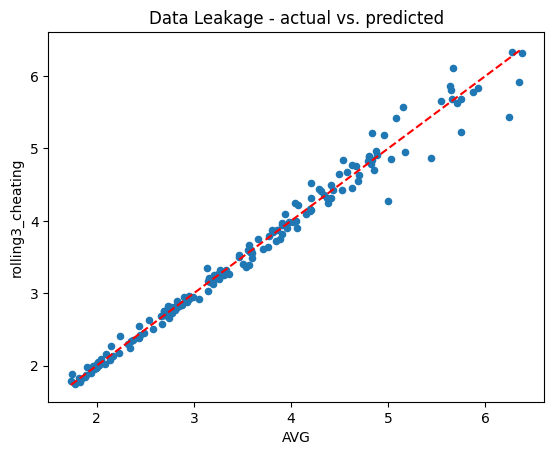

In [558]:
# scatterplot of actual vs. predicted
tmp.plot.scatter(x='AVG', # actual
                 y = 'rolling3_cheating')
# Add the 45 degree line
plt.plot([min(tmp['AVG']), max(tmp['AVG'])], [min(tmp['AVG']), max(tmp['AVG'])], color='red', linestyle='dashed')

plt.title('Data Leakage - actual vs. predicted')
plt.show()

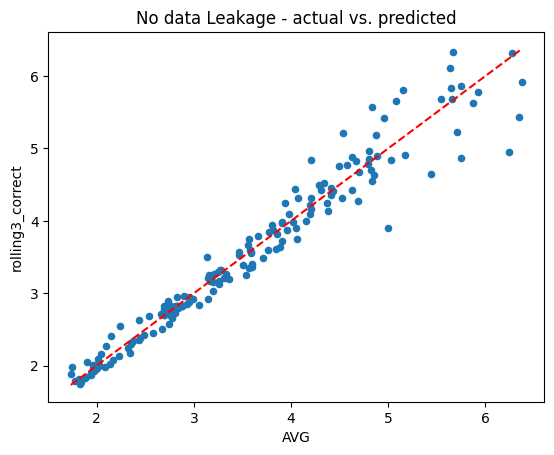

In [559]:
# scatterplot of actual vs. predicted
tmp.plot.scatter(x='AVG', # actual
                 y = 'rolling3_correct')
# Add the 45 degree line
plt.plot([min(tmp['AVG']), max(tmp['AVG'])], [min(tmp['AVG']), max(tmp['AVG'])], color='red', linestyle='dashed')

plt.title('No data Leakage - actual vs. predicted')
plt.show()

## Evaluate the error metrics

In [560]:
# prompt: using sklearn, evaluate r2, mae, mape and bias for actual vs. predicted

from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

actual = tmp['AVG']
predicted_cheating = tmp['rolling3_cheating']
predicted_correct = tmp['rolling3_correct']

# R2
r2_cheating = r2_score(actual, predicted_cheating)
r2_correct = r2_score(actual, predicted_correct)

# MAE
mae_cheating = mean_absolute_error(actual, predicted_cheating)
mae_correct = mean_absolute_error(actual, predicted_correct)

# MAPE
mape_cheating = mean_absolute_percentage_error(actual, predicted_cheating)
mape_correct = mean_absolute_percentage_error(actual, predicted_correct)

# Bias
bias_cheating = np.mean(predicted_cheating - actual)
bias_correct = np.mean(predicted_correct - actual)

# Print the results
print("Evaluation metrics for data leakage:")
print("- R2:", r2_cheating)
print("- MAE:", mae_cheating)
print("- MAPE:", mape_cheating)
print("- Bias:", bias_cheating)

print("\nEvaluation metrics without data leakage:")
print("- R2:", r2_correct)
print("- MAE:", mae_correct)
print("- MAPE:", mape_correct)
print("- Bias:", bias_correct)


Evaluation metrics for data leakage:
- R2: 0.9852044139077272
- MAE: 0.0793267326732673
- MAPE: 0.020649215046833095
- Bias: -0.0070462046204620475

Evaluation metrics without data leakage:
- R2: 0.9553633553581132
- MAE: 0.14448349834983493
- MAPE: 0.03790138230672984
- Bias: -0.013922442244224422


## Time Series Plots

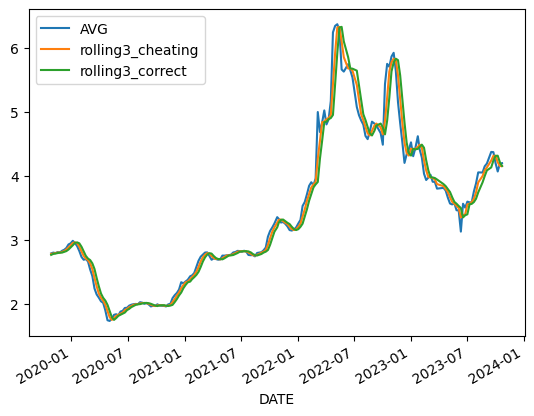

In [561]:
tmp.plot()
plt.show()

# 🔴 The RIGHT WAY!

In [562]:
df.head()

,AVG,HIGH,LOW
DATE,,,
2019-10-07,2.743,3.849,2.329
2019-10-14,2.788,3.849,2.340
2019-10-21,2.770,3.849,2.299
2019-10-28,2.790,3.739,2.379
2019-11-04,2.803,3.999,2.340


In [563]:
# the window
myWindow = 3

In [564]:
# play with the window!
df['PRED'] = df['AVG'].shift(1).rolling(window=myWindow).mean()
df.head(n=15)

,AVG,HIGH,LOW,PRED
DATE,,,,
2019-10-07,2.743,3.849,2.329,NaN
2019-10-14,2.788,3.849,2.340,NaN
2019-10-21,2.770,3.849,2.299,NaN
2019-10-28,2.790,3.739,2.379,2.767000
2019-11-04,2.803,3.999,2.340,2.782667
2019-11-11,2.795,3.999,2.299,2.787667
2019-11-18,2.811,3.990,2.299,2.796000
2019-11-25,2.801,3.999,2.379,2.803000
2019-12-02,2.831,4.049,2.379,2.802333


In [565]:
# drop missing values!
df.dropna(inplace=True)

In [566]:
df.tail()

,AVG,HIGH,LOW,PRED
DATE,,,,
2023-09-25,4.374,5.400,3.70,4.241667
2023-10-02,4.203,5.699,3.68,4.315333
2023-10-09,4.071,5.299,3.48,4.318000
2023-10-16,4.196,5.366,3.71,4.216000
2023-10-23,4.201,5.399,3.66,4.156667


## Error metrics

In [567]:
# specify actual and pred columns
actual = df['AVG']
predicted = df['PRED']

In [568]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

# R2
r2 = r2_score(actual, predicted)

# MAE
mae = mean_absolute_error(actual, predicted)

# MAPE
mape = mean_absolute_percentage_error(actual, predicted)

# Bias
bias = np.mean(predicted - actual)


# Print the results
print("Evaluation metrics for data leakage:")
print("- R2:", r2)
print("- MAE:", mae)
print("- MAPE:", mape)
print("- Bias:", bias)

Evaluation metrics for data leakage:
- R2: 0.9553633553581132
- MAE: 0.14448349834983493
- MAPE: 0.03790138230672984
- Bias: -0.013922442244224422


## Scatterplot

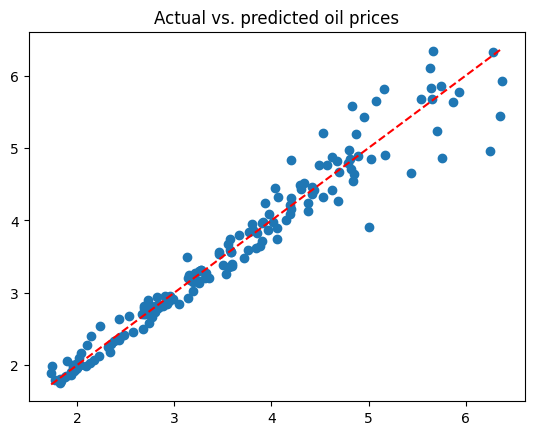

In [569]:
# scatterplot of actual vs. predicted
plt.scatter(x=actual, # actual
                 y = predicted)
# Add the 45 degree line
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linestyle='dashed')

plt.title('Actual vs. predicted oil prices')
plt.show()

## Time Series Plot

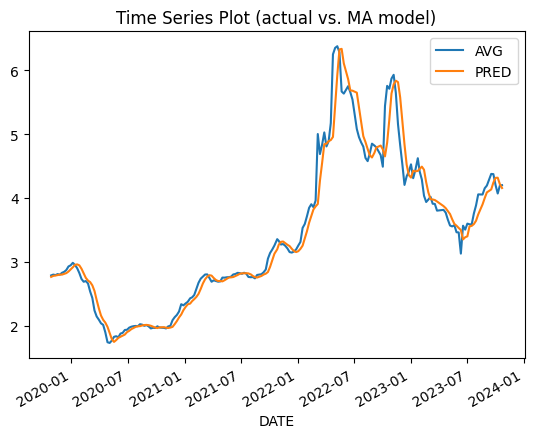

In [570]:
df[['AVG', 'PRED']].plot()
plt.title('Time Series Plot (actual vs. MA model)')
plt.show()

# 🦾 On your own
* See if you can add 'myWindow' to all of the plot titles!
* Advanced (optional): See you if you can use chatGPT to help you turn this into an efficient FUNCTION!!! Ask Dave in Office Hours for more details or a demo...